<a href="https://colab.research.google.com/github/Dnntello/Prodigy_ML_01/blob/main/linear_regression_model_for_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import zipfile

# zip_path = "/content/drive/MyDrive/building linear regression/house-prices-advanced-regression-techniques.zip"
# extract_path = "/content/drive/MyDrive/building linear regression/data"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#   zip_ref.extractall(extract_path)

In [ ]:
#importing important libraries and reading training csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_path = "/content/drive/MyDrive/building linear regression/data/train.csv"

data = pd.read_csv(train_path)
data.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
!ls

drive  sample_data


<Axes: >

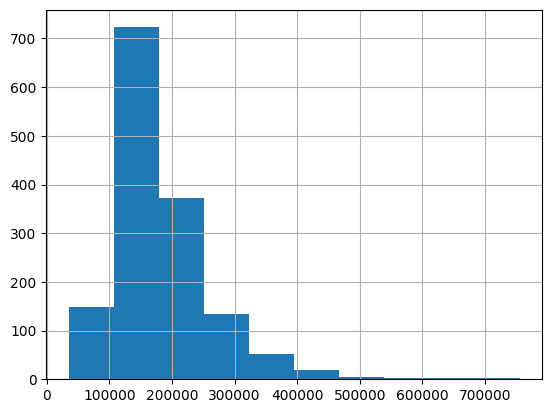

In [ ]:
data['SalePrice'].hist()

## There are time related data amongst our dataset
* YearBuilt
* YearRemodAdd
* GarageYrBlt
* YrSold
* MoSold

Thus we need to engineer more columns to appreciate this data


In [ ]:
#lets create helpful enginered features

data['HouseAge'] = data['YrSold'] - data['YearBuilt']
data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
data['GarageAge'] = data['YrSold'] - data['GarageYrBlt']

#to let our machine know that january is close to december
data['MoSoldSin'] = np.sin(2 * np.pi * data['MoSold'] / 12)
data['MoSoldCos'] = np.cos(2 * np.pi * data["MoSold"] / 12)


In [ ]:
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
HouseAge,0
RemodAge,0
GarageAge,81
MoSoldSin,0


In [ ]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Missing values

Operations are needed to be carried out on the available missing values

In [ ]:
missing_columns = []

for i in data.columns:
  if data[i].isna().sum() > 0:
    missing_columns.append(i)

missing_columns

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'GarageAge']

In [ ]:
#to get numerical missing values
numeric_missing_cols = data[missing_columns].select_dtypes(include='number').columns.tolist()
numeric_missing_cols

['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'GarageAge']

In [ ]:
#to find the length of fields
len(data)

1460

In [ ]:
print(f"Lefrontage sum: {data['LotFrontage'].isna().sum()} and mean: {data['LotFrontage'].mean()}")
print(f"MasVnrArea sum: {data['MasVnrArea'].isna().sum()} and mean: {data['MasVnrArea'].mean()}")
print(f"GarageYrBlt sum: {data['GarageYrBlt'].isna().sum()} and mean: {data['GarageYrBlt'].mean()}")

Lefrontage sum: 259 and mean: 70.04995836802665
MasVnrArea sum: 8 and mean: 103.68526170798899
GarageYrBlt sum: 81 and mean: 1978.5061638868744


In [ ]:
categorical_missing_columns = [data for data in missing_columns if data not in numeric_missing_cols]
categorical_missing_columns

['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [ ]:
for i in range(len(categorical_missing_columns)):
  print(f"{categorical_missing_columns[i]} sum of missing: {data[categorical_missing_columns[i]].isna().sum()}")

Alley sum of missing: 1369
MasVnrType sum of missing: 872
BsmtQual sum of missing: 37
BsmtCond sum of missing: 37
BsmtExposure sum of missing: 38
BsmtFinType1 sum of missing: 37
BsmtFinType2 sum of missing: 38
Electrical sum of missing: 1
FireplaceQu sum of missing: 690
GarageType sum of missing: 81
GarageFinish sum of missing: 81
GarageQual sum of missing: 81
GarageCond sum of missing: 81
PoolQC sum of missing: 1453
Fence sum of missing: 1179
MiscFeature sum of missing: 1406


In [ ]:
data['MasVnrType'].value_counts()

,count
MasVnrType,
BrkFace,445
Stone,128
BrkCmn,15


In [ ]:
#removing columns which have very large missing values except Masonery veneer type

data.drop("Alley", axis=1, inplace=True)
data.drop("PoolQC", axis=1, inplace=True)
data.drop("Fence", axis=1, inplace=True)
data.drop("MiscFeature", axis=1, inplace=True)
data.drop("FireplaceQu", axis=1, inplace=True)

In [ ]:
#filling all missing values with "none" in Masonry Veneer type
data.fillna({"MasVnrType": "None"}, inplace=True)

In [ ]:
#to update our categorical_missing columns
missing_values = []

for i in data.columns:
  if data[i].isna().sum()>0:
    missing_values.append(i)

categorical_missing_columns = data[missing_values].select_dtypes(exclude='number').columns.tolist()
categorical_missing_columns

['BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond']

In [ ]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

data[numeric_missing_cols] = num_imputer.fit_transform(data[numeric_missing_cols])
data[categorical_missing_columns] = cat_imputer.fit_transform(data[categorical_missing_columns])



In [ ]:
# now to check for missing values
data.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
HouseAge,0
RemodAge,0
GarageAge,0
MoSoldSin,0


## Now to turn categorical features into numeric values for modelling

First, we split into X and Y

In [ ]:
X = data.drop("SalePrice", axis = 1)
y = data["SalePrice"]

In [ ]:
data.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
HouseAge,int64
RemodAge,int64
GarageAge,float64
MoSoldSin,float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_transformed = preprocessor.fit_transform(X)

In [ ]:
X_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 99164 stored elements and shape (1460, 276)>

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)

## Now to create our model
We are going to use Linear regression model (I also tried Random Forest Regressor by the side and it gave me better results)

In [ ]:
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(random_state=42)
# model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.score(X_train, y_train)

0.8994823639365881

In [ ]:
model.score(X_val, y_val)

0.8767776577653388

In [ ]:
print(model.predict(X_val[:10]) - y_val[:10])

892     -3982.244419
1105    27396.465968
413    -15331.141652
522     18764.519456
1036    22564.417732
614    -18995.175904
218    -60847.936401
1160     3654.308145
649    -26616.487518
887     11378.165428
Name: SalePrice, dtype: float64


In [ ]:
y.mean()

np.float64(180921.19589041095)

In [ ]:
y_preds = model.predict(X_val)

## Now to evaluate our model properly

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(y_val, y_preds):
  """
  This functions returns the metrics of our model
  in order of MAE, MSE, RMSE, R2
  """
  mae = mean_absolute_error(y_val, y_preds)
  mse = mean_squared_error(y_val, y_preds)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_val, y_preds)
  return mae, mse, rmse, r2

In [ ]:
mae, mse, rmse, r2 = metrics(y_val, y_preds)
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 17665.501198630136
MSE: 838484886.3794537
RMSE: 28956.603502128037
R2: 0.890684585801085


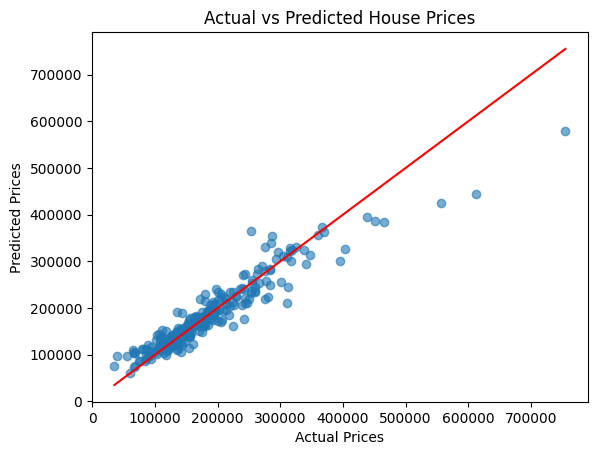

In [ ]:
plt.figure()

plt.scatter(y_val, y_preds, alpha=0.6)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

# perfect prediction line
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color='red')

plt.show()

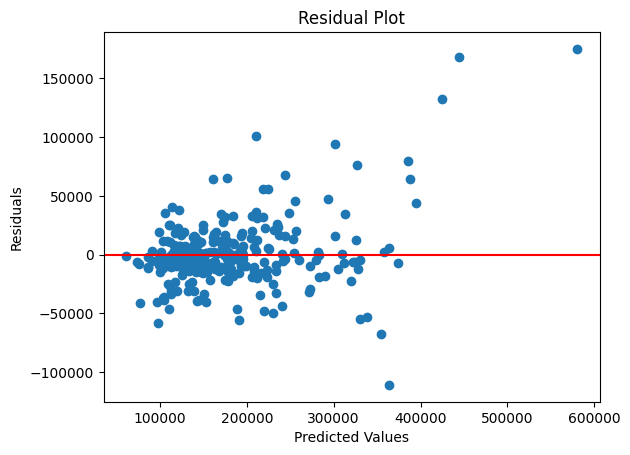

In [ ]:
residuals = y_val - y_preds

plt.figure()
plt.scatter(y_preds, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Since linear regressor models do not often improve with hyperparameter tuning, we are going to skip that

In [ ]:
#to save our model
import joblib

joblib.dump(model, 'drive/MyDrive/building linear regression/model2.pkl')

['drive/MyDrive/building linear regression/model2.pkl']

In [ ]:
#load our model
model = joblib.load('drive/MyDrive/building linear regression/model1.pkl')

## lets work on our test file

In [ ]:
test_path = "drive/MyDrive/building linear regression/data/test.csv"

test_data = pd.read_csv(test_path)
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
for i in test_data.columns:
  if test_data[i].isna().sum() > 0:
    print(i)

MSZoning
LotFrontage
Alley
Utilities
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
BsmtFullBath
BsmtHalfBath
KitchenQual
Functional
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageArea
GarageQual
GarageCond
PoolQC
Fence
MiscFeature
SaleType


In [ ]:
for col in data.columns:
    if data[col].apply(lambda x: isinstance(x, (list, tuple, dict))).any():
        print("Bad column:", col)

In [ ]:
data = test_data.copy()
#lets create helpful enginered features

data['HouseAge'] = data['YrSold'] - data['YearBuilt']
data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
data['GarageAge'] = data['YrSold'] - data['GarageYrBlt']

#to let our machine know that january is close to december
data['MoSoldSin'] = np.sin(2 * np.pi * data['MoSold'] / 12)
data['MoSoldCos'] = np.cos(2 * np.pi * data["MoSold"] / 12)

#removing columns which have very large missing values except Masonery veneer type

data.drop("Alley", axis=1, inplace=True)
data.drop("PoolQC", axis=1, inplace=True)
data.drop("Fence", axis=1, inplace=True)
data.drop("MiscFeature", axis=1, inplace=True)
data.drop("FireplaceQu", axis=1, inplace=True)
#filling all missing values with "none" in Masonry Veneer type
data.fillna({"MasVnrType": "None"}, inplace=True)

missing_columns = []

for i in data.columns:
  if data[i].isna().sum() > 0:
    missing_columns.append(i)

#to get numerical and categorical missing values
numeric_missing_cols = data[missing_columns].select_dtypes(include='number').columns.tolist()
categorical_missing_columns = [data for data in missing_columns if data not in numeric_missing_cols]

categorical_missing_columns = data[missing_values].select_dtypes(exclude='number').columns.tolist()

num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

data[numeric_missing_cols] = num_imputer.fit_transform(data[numeric_missing_cols])
data[categorical_missing_columns] = cat_imputer.fit_transform(data[categorical_missing_columns])

categorical_cols = data.select_dtypes(include='object').columns

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
#     ],
#     remainder='passthrough'
#)

transformed_test= preprocessor.transform(data)

In [ ]:
transformed_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 99150 stored elements and shape (1459, 276)>

In [ ]:
y_preds = model.predict(transformed_test)

In [ ]:
type(transformed_test)

scipy.sparse._csr.csr_matrix

In [ ]:
y_preds

array([129860.55, 153632.  , 179780.34, ..., 154029.6 , 117627.5 ,
       221589.65])

In [ ]:
#lets turn our y_preds into submission format
submission = pd.DataFrame({'Id': test_data["Id"],
                           'SalePrice': y_preds})

In [ ]:
submission.head()

,Id,SalePrice
0,1461,129860.55
1,1462,153632.00
2,1463,179780.34
3,1464,186448.32
4,1465,205987.00


In [ ]:
submission.to_csv("drive/MyDrive/building linear regression/submission.csv",
                  index = False)